### Neuronas sin uso de bibliotecas 

In [1]:
import math 
import random

#funcion de activacion sigmoide, es muy utilizada sin embargo, tiene muchas limitantes 
def sigmoid(x):
    return 1 / (1+math.exp(-x))

#neruona simple 
class Neurona: 
    def __init__(self, n_inputs):
        self.weights = [random.random() for _ in range(n_inputs)]
        self.bias = random.random()

    def forward(self, inputs):
        z = sum(w * x for w, x in zip(self.weights, inputs)) + self.bias
        return sigmoid(z)
    
#creando instancia de neurona 
neuron = Neurona(2)

output = neuron.forward([0.5, 0.8])
print("Salida: ", output)

Salida:  0.8143010276870616


In [2]:
def sigmoid_derivation(x):
    return x*(1-x)

class Neuron: 
    def __init__(self, n_inputs):
        self.weights = [random.random() for _ in range(n_inputs)]
        self.bias = random.random()

    #forward
    def forward(self, inputs):
        self.inputs = inputs
        self.z = sum(w*x for w , x in zip(self.weights, inputs))
        self.output = sigmoid(self.z)
        return self.output
    
    #backward
    def backward(self, target, lr):
        error = target - self.output
        d_output = error * sigmoid_derivation(self.output)

        #actualizar los pesos de las neuronas 
        for i in range(len(self.weights)):
            self.weights[i] += lr * d_output * self.inputs[i]
        self.bias += lr*d_output    

#introduccion de datos
data = [
    ([0,0],0),
    ([0,1],1),
    ([1,0],1),
    ([1,1],1),
]

neuron = Neuron(2)

for epoch in range(100000):
    for x,y in data:
        neuron.forward(x)
        neuron.backward(y,0.1)

for x, _ in data:
    print(x, neuron.forward(x))

[0, 0] 0.5
[0, 1] 0.9928278182439882
[1, 0] 0.9928316756903562
[1, 1] 0.9999478449075963


## Funciones de activacion 


In [6]:
import math 

#funcion de activacion sigmoide rango 0,1
def sigmoid(x):
    return 1 / (1+math.exp(-x))

#funcion de activacion tangh -1,1
def tanh(x):
    return math.tanh(x)

#funcion relu
def relu(x):
    return max(0,x)

In [10]:
inputs = [-5,-2,-1,0,1,2,5]

print("x \tSigmoid\t\tReLU\t\tTanh")
for x in inputs:
    print(f"{x}\t{sigmoid(x):.4f}\t\t{relu(x):.4f}\t\t{tanh(x):.4f}")

x 	Sigmoid		ReLU		Tanh
-5	0.0067		0.0000		-0.9999
-2	0.1192		0.0000		-0.9640
-1	0.2689		0.0000		-0.7616
0	0.5000		0.0000		0.0000
1	0.7311		1.0000		0.7616
2	0.8808		2.0000		0.9640
5	0.9933		5.0000		0.9999


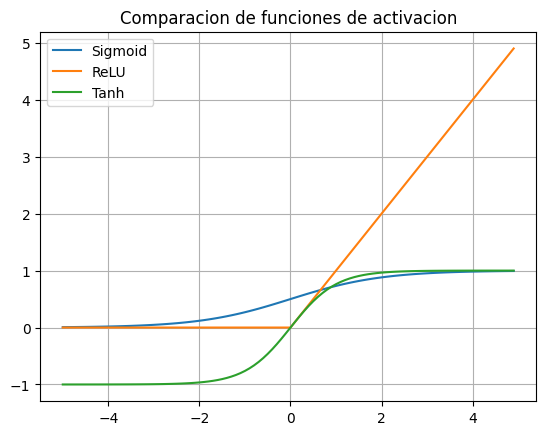

In [11]:
#visualizacion 
import matplotlib.pyplot as plt 

#generando valores numericos entre el rango de -50 al 50
x_vals = [i * 0.1 for i in range(-50,50)]

#introduccion de valores numericos entre las funciones de activacion
sigmoid_vals = [sigmoid(x) for x in x_vals]
relu_vals = [relu(x) for x in x_vals]
tanh_vals = [tanh(x) for x in x_vals]

#generando la grafica 
plt.plot(x_vals, sigmoid_vals, label="Sigmoid")
plt.plot(x_vals, relu_vals, label="ReLU")
plt.plot(x_vals, tanh_vals, label="Tanh")

plt.legend()
plt.title("Comparacion de funciones de activacion")
plt.grid()

In [13]:
#apliacion de las funciones en una neurona 
#creando la clase neurona 
class Neuron:
    def __init__(self,n_inputs, activation):
        import random
        self.weights = [random.random() for _ in range(n_inputs)]
        self.bias = random.random()
        self.activacion = activation

    #forward 
    def forward(self, inputs):
        z = sum(w*x for w,x in zip(self.weights, inputs)) + self.bias
        return self.activacion(z)

#creando los inputs 
inputs = [0.5,0.8]

neurona_sigmoide = Neuron(2, sigmoid)
neurona_tanh = Neuron(2, tanh)
neurona_relu = Neuron(2,relu)

print("Sigmoid: ", neurona_sigmoide.forward(inputs))
print("Tanh: ", neurona_tanh.forward(inputs))
print("ReLU: ", neurona_relu.forward(inputs))

Sigmoid:  0.6832030430738124
Tanh:  0.8745677899466539
ReLU:  1.6851815813103168


### Comparacion entre funciones de activacion
El proposito de esta parte del notebook es visualizar los diferentes comportamientos de una neurona en entrenamiento con el uso de las tres funciones de activacion, visualizando lo siguiente: 
* diferencia en la tasa de error
* velocidad de entrenamiento 
* comparacion final

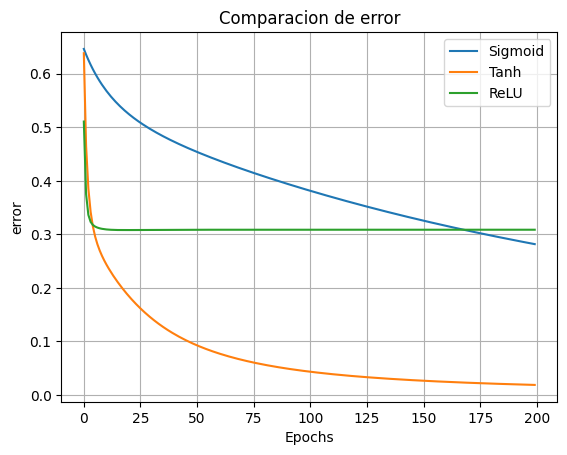

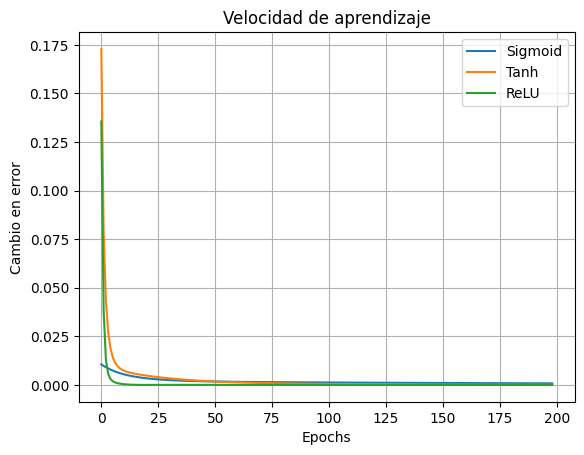

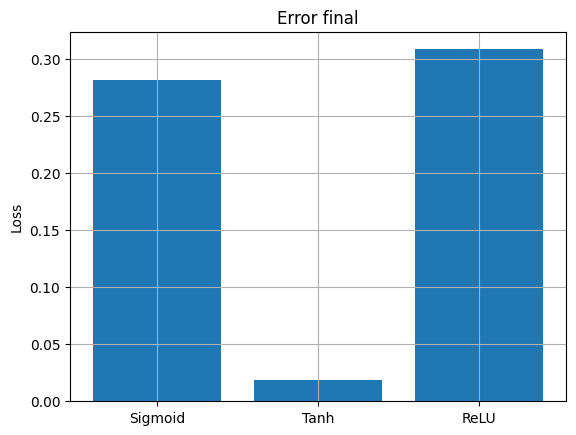

In [3]:
import math 
import random
import matplotlib.pyplot as plt 

#funciones de activacion junto con sus derivadas 
def sigmoid(x):
    return 1/(1+math.exp(-x))

def sigmoid_dev(y):
    return y*(1-y)

def tanh(x):
    return math.tanh(x)

def tanh_dev(y):
    return 1-y**2

def relu(x):
    return max(0,x)

def relu_dev(y):
    return 1 if y > 0 else 0


class Neuron:
    def __init__(self,weights,bias, activation, deriv):
        import random
        self.weights = weights
        self.bias = bias
        self.activacion = activation
        self.deriv = deriv

    #forward 
    def forward(self, inputs):
        self.inputs = inputs
        self.z = sum(w*x for w,x in zip(self.weights, inputs)) + self.bias
        self.output = self.activacion(self.z)
        return self.output
    
    #backward
    def backward(self, target, lr):
        error = target - self.output
        grad = error * self.deriv(self.output)

        for i in range(len(self.weights)):
            self.weights[i] += lr*grad*self.inputs[i]

        self.bias += lr*grad

        return error**2 
    
#dataset con la logica OR

data =[
    ([0,0],0),
    ([0,1],1),
    ([1,0],1),
    ([1,1],1)
]

#proceso de entrenamiento 
def train_model(activation, deriv, epochs=200):

    #mismos pesos iniciales 
    base_weights = [0.5,0.3]
    base_bias = 0.1

    #creando la instancia de la neurona 
    neuron = Neuron(base_weights,base_bias, activation, deriv)

    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for x,y in data:
            neuron.forward(x)#propagacion de los datos 
            loss = neuron.backward(y,0.1)
            total_loss += loss

        losses.append(total_loss)

    return losses

#ejecutando el entrenamiento 

loss_sigmoid = train_model(sigmoid,sigmoid_dev)
loss_tanh = train_model(tanh, tanh_dev)
loss_relu = train_model(relu, relu_dev)

#etapa de graficas de compracion entre funciones de activacion y tasa de error 

#grafica de error 
plt.figure()
plt.plot(loss_sigmoid,label="Sigmoid")
plt.plot(loss_tanh, label="Tanh")
plt.plot(loss_relu,label="ReLU")

plt.title("Comparacion de error")
plt.xlabel("Epochs")
plt.ylabel("error")
plt.legend()
plt.grid()
plt.show()

#grafica de velocidad de entrenamiento 
def speed(loss):
    return [abs(loss[i] - loss[i-1]) for i in range(1, len(loss))]

plt.figure()
plt.plot(speed(loss_sigmoid),label="Sigmoid")
plt.plot(speed(loss_tanh), label="Tanh")
plt.plot(speed(loss_relu),label="ReLU")

plt.title("Velocidad de aprendizaje")
plt.xlabel("Epochs")
plt.ylabel("Cambio en error")
plt.legend()
plt.grid()
plt.show()

#Comparacion final 
final_losses = [
    loss_sigmoid[-1],
    loss_tanh[-1],
    loss_relu[-1]
]

labels = ["Sigmoid", "Tanh","ReLU"]

plt.figure()
plt.bar(labels,final_losses)

plt.title("Error final")
plt.ylabel("Loss")
plt.grid()
plt.show()

### Funciones de optmizacion